# **Employee Attrition Prediction using ML**

**Goal:** Predict whether an employee will leave the company (`attrition`) using HR, work-life, and engagement data.

### **What this notebook covers**
1. Data loading & exploration
2. Exploratory Data Analysis (EDA)
3. Data cleaning & leakage check
4. Preprocessing (encoding, scaling)
5. Handling class imbalance
6. Model building (Logistic Regression, Random Forest, XGBoost, LightGBM)
7. Model evaluation & comparison
8. Feature importance
9. Conclusion


## **1. Import Libraries**
We start by importing all the tools (libraries) we'll need for data handling, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries imported successfully!")

Libraries imported successfully!


## **2. Load & Explore the Dataset**
Let's load the CSV file and take a first look at its shape, columns, and sample rows.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/uditjain13/employee-attrition-and-hr-analytics-2026/employee_attrition_hr_2026.csv')

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (5000, 29)


,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,...,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
0,1001,37,Male,Divorced,Masters,Engineering,Engineering Manager,3,7365,0,...,17,9.4,1.0,9.7,7.7,3,8.3,True,4.8,No
1,1002,24,Female,Married,Bachelors,Finance,Finance Manager,2,4746,2,...,21,4.2,1.9,5.4,7.8,3,8.0,True,2.9,Yes
2,1003,24,Female,Single,Bachelors,Marketing,Marketing Specialist,1,2740,2,...,22,7.5,5.3,6.5,7.0,4,9.5,True,7.2,No
3,1004,44,Male,Single,Bachelors,Sales,Sales Manager,4,7334,1,...,21,8.7,4.3,7.3,3.5,4,7.9,False,5.2,No
4,1005,37,Female,Divorced,Bachelors,Sales,Sales Development Rep,3,9096,0,...,20,7.5,2.3,7.0,7.2,4,8.5,False,6.4,No


In [3]:
# Basic info about columns and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   employee_id                    5000 non-null   int64  
 1   age                            5000 non-null   int64  
 2   gender                         5000 non-null   object 
 3   marital_status                 5000 non-null   object 
 4   education_level                5000 non-null   object 
 5   department                     5000 non-null   object 
 6   job_role                       5000 non-null   object 
 7   job_level                      5000 non-null   int64  
 8   monthly_income                 5000 non-null   int64  
 9   stock_option_level             5000 non-null   int64  
 10  salary_hike_pct                5000 non-null   float64
 11  years_at_company               5000 non-null   float64
 12  total_working_years            5000 non-null   f

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

Missing values per column:
0 total missing values


**Observation:** The dataset has no missing values, which makes preprocessing simpler.

## **3. Exploratory Data Analysis (EDA)**
Let's understand the target variable and how it relates to other features.

attrition
No     4105
Yes     895
Name: count, dtype: int64

Attrition rate: 17.9%


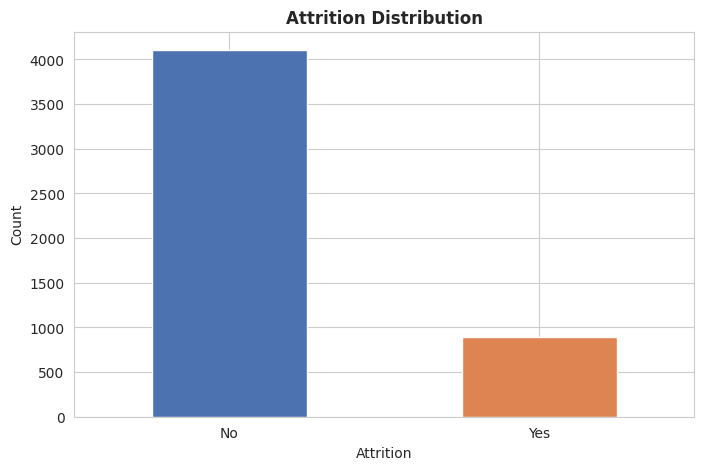

In [5]:
# Target variable distribution
attrition_counts = df['attrition'].value_counts()
print(attrition_counts)
print("\nAttrition rate: {:.1f}%".format(100 * attrition_counts['Yes'] / len(df)))

attrition_counts.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Attrition Distribution',fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**Observation:** The dataset is imbalanced — only about 18% of employees left the company. We'll handle this later using SMOTE.

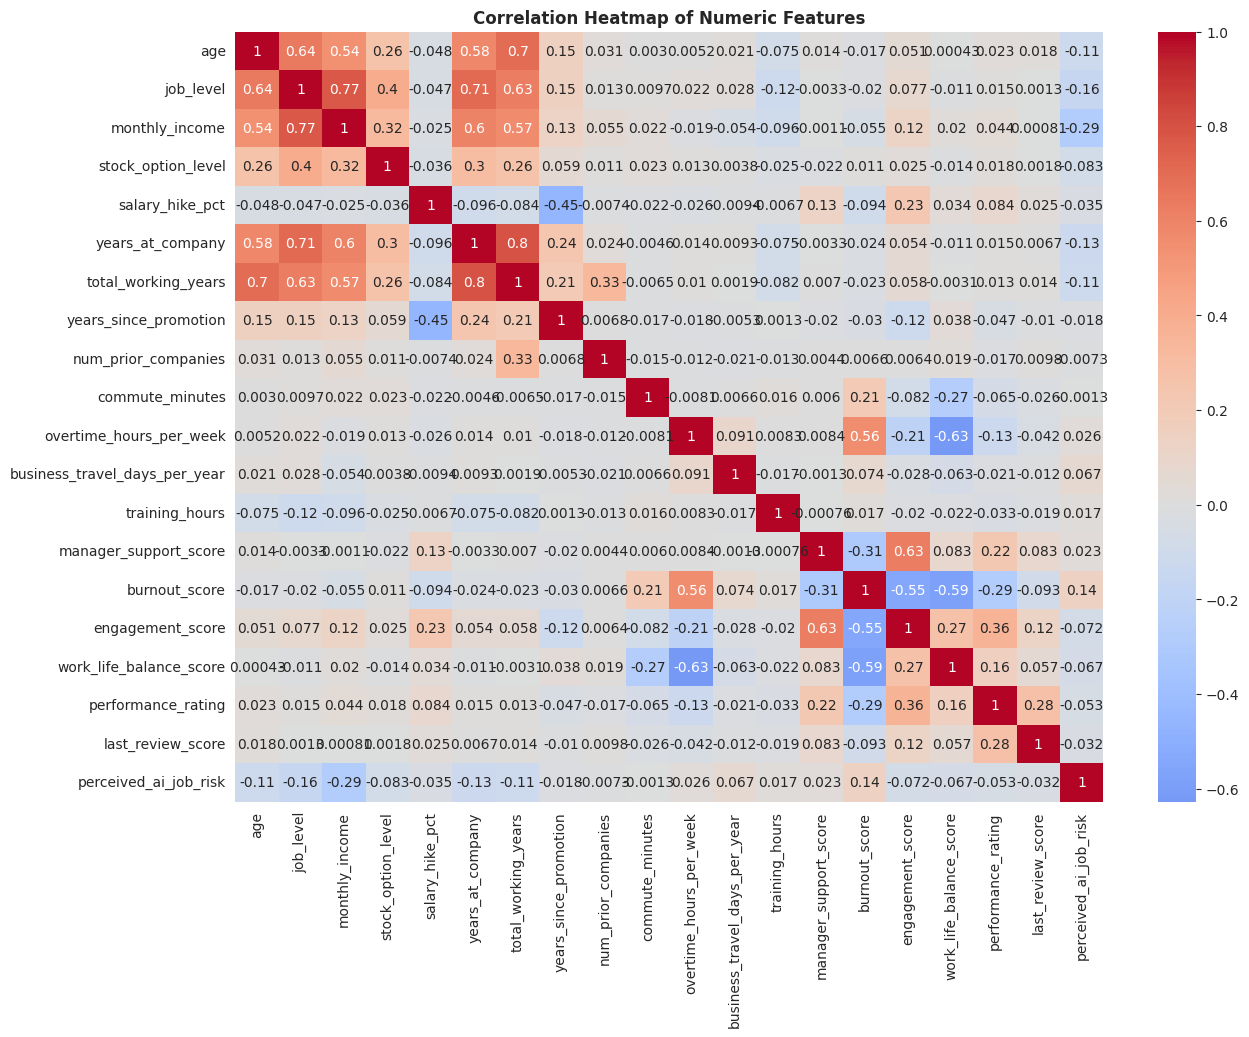

In [6]:
# Numeric feature correlation with each other
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['employee_id'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=True)
plt.title('Correlation Heatmap of Numeric Features',fontweight='bold')
plt.show()

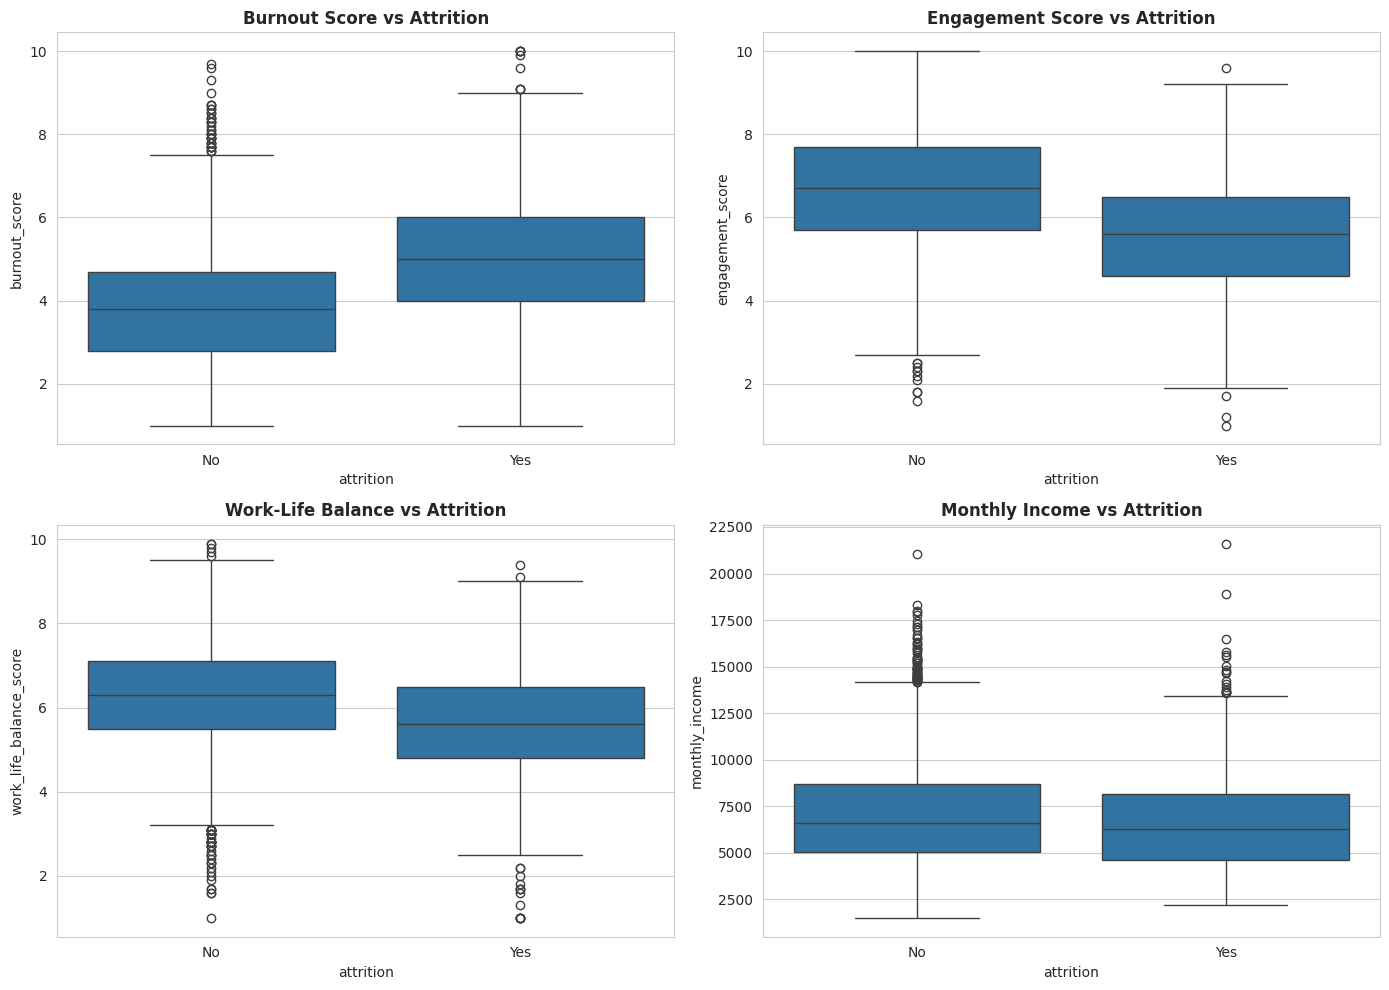

In [7]:
# How key features differ by attrition status
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='attrition', y='burnout_score', ax=axes[0,0])
axes[0,0].set_title('Burnout Score vs Attrition',fontweight='bold')

sns.boxplot(data=df, x='attrition', y='engagement_score', ax=axes[0,1])
axes[0,1].set_title('Engagement Score vs Attrition',fontweight='bold')

sns.boxplot(data=df, x='attrition', y='work_life_balance_score', ax=axes[1,0])
axes[1,0].set_title('Work-Life Balance vs Attrition',fontweight='bold')

sns.boxplot(data=df, x='attrition', y='monthly_income', ax=axes[1,1])
axes[1,1].set_title('Monthly Income vs Attrition',fontweight='bold')

plt.tight_layout()
plt.show()

**Observation:** Employees who leave tend to have higher burnout, lower engagement, and lower work-life balance scores — these look like strong predictive signals.

## **4. Data Cleaning & Leakage Check**
Before modeling, we must remove columns that don't help prediction or that could **leak** information about the outcome:
- `employee_id` is just a unique identifier — it carries no real signal and can cause overfitting, so we drop it.
- We checked all other columns and none of them directly encode the target (e.g. no "resignation_date" or "exit_reason" column exists), so there is **no data leakage** in this dataset.

In [8]:
df_model = df.drop(columns=['employee_id'])

# Convert boolean column to int (0/1)
df_model['uses_ai_tools_at_work'] = df_model['uses_ai_tools_at_work'].astype(int)

print("Columns used for modeling:", df_model.shape[1] - 1)

Columns used for modeling: 27


## **5. Preprocessing**
We encode categorical (text) columns into numbers so the ML models can understand them, and separate features (X) from the target (y).

In [9]:
# Encode target: Yes -> 1, No -> 0
df_model['attrition'] = df_model['attrition'].map({'Yes': 1, 'No': 0})

# One-hot encode categorical columns
categorical_cols = ['gender', 'marital_status', 'education_level',
                     'department', 'job_role', 'work_mode']

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

X = df_model.drop(columns=['attrition'])
y = df_model['attrition']

print("Final feature shape:", X.shape)

Final feature shape: (5000, 62)


In [10]:
# Train-test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4000, 62)
Test shape: (1000, 62)


In [11]:
# Scale numeric features (helps Logistic Regression converge better)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **6. Handling Class Imbalance**
Since only ~18% of employees leave, models can get lazy and just predict "No" every time. We use **SMOTE** (Synthetic Minority Oversampling) on the training data only, to balance the classes.

In [12]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_bal.value_counts().to_dict())

Before SMOTE: {0: 3284, 1: 716}
After SMOTE: {0: 3284, 1: 3284}


## **7. Model Building**
We'll train and compare 4 models:
- **Logistic Regression** — simple, interpretable baseline
- **Random Forest** — bagging-based tree ensemble
- **XGBoost** — gradient boosting, usually strong on tabular data
- **LightGBM** — fast gradient boosting, handles large data well

Each model is trained on the balanced data and evaluated on the untouched test set.

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                random_state=42, verbose=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.727,0.360947,0.681564,0.471954,0.801251
1,Random Forest,0.787,0.423423,0.525140,0.468828,0.773182
2,XGBoost,0.832,0.561798,0.279330,0.373134,0.772263
3,LightGBM,0.821,0.500000,0.223464,0.308880,0.752237


## **8. Model Evaluation & Comparison**
Let's visualize how the models compare, then look closely at the best one.

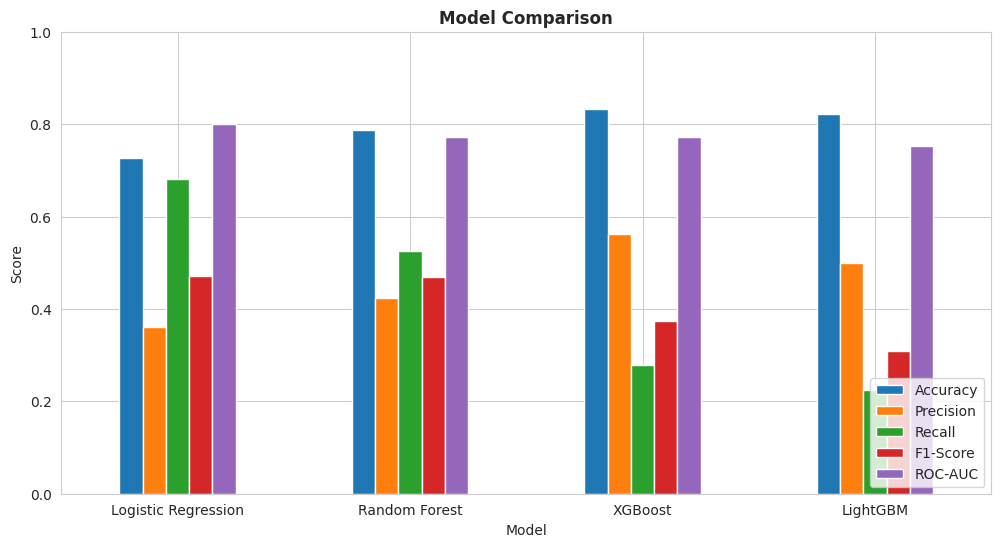

In [14]:
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(12, 6))
plt.title('Model Comparison',fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.show()

In [15]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")

y_pred_best = best_model.predict(X_test_scaled)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=['Stayed', 'Left']))

Best model: Logistic Regression

Classification Report:

              precision    recall  f1-score   support

      Stayed       0.91      0.74      0.82       821
        Left       0.36      0.68      0.47       179

    accuracy                           0.73      1000
   macro avg       0.64      0.71      0.64      1000
weighted avg       0.81      0.73      0.75      1000



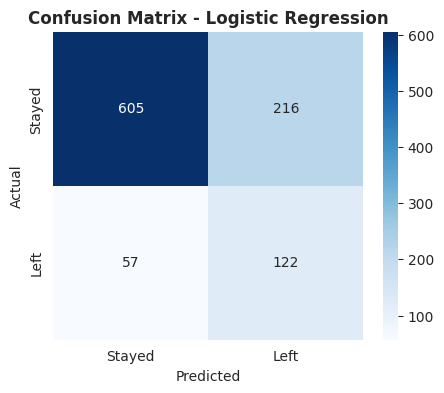

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title(f'Confusion Matrix - {best_model_name}',fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

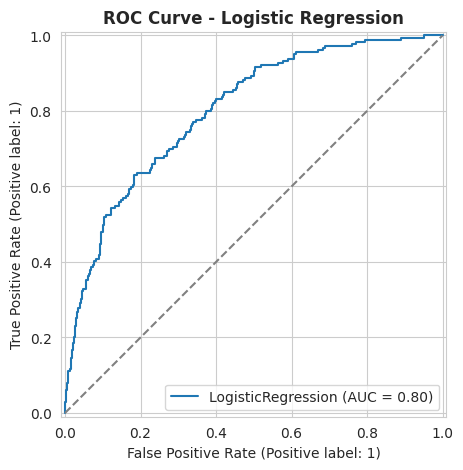

In [17]:
# ROC Curve for the best model
RocCurveDisplay.from_estimator(best_model, X_test_scaled, y_test)
plt.title(f'ROC Curve - {best_model_name}',fontweight='bold')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.show()

## **9. Feature Importance**
Which factors matter most in predicting attrition?

In [18]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top_features = importances.sort_values(ascending=False).head(12)

    plt.figure(figsize=(9, 6))
    sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
    plt.title(f'Top 12 Important Features - {best_model_name}')
    plt.xlabel('Importance')
    plt.show()
else:
    print("Selected model does not expose feature_importances_ directly.")

Selected model does not expose feature_importances_ directly.


In [19]:
from IPython.display import Markdown, display

best_row = results_df.iloc[0]
summary = f"""
## **10. Conclusion**

- We built and compared **4 classification models** to predict employee attrition, after confirming the dataset had **no missing values and no data leakage**.
- Class imbalance (~18% attrition) was handled using **SMOTE** on the training set only, keeping the test set realistic and untouched.
- The best performing model was **{best_row['Model']}**, achieving **{best_row['Accuracy']:.1%} accuracy**, **{best_row['F1-Score']:.2f} F1-score**, and **{best_row['ROC-AUC']:.2f} ROC-AUC** — meaning it balances catching actual leavers with not over-flagging employees who stay.
- The most influential drivers of attrition were features like **burnout score, engagement score, work-life balance, and monthly income** — aligning with real-world HR intuition.
- **Business takeaway:** HR teams could use this model to flag at-risk employees early and proactively address burnout and engagement issues, potentially reducing costly turnover.

**Next steps (ideas for extension):**
- Hyperparameter tuning (GridSearchCV / Optuna) for further score improvement
- Try SHAP values for deeper feature interpretability
- Collect more historical data to strengthen the model over time
"""
display(Markdown(summary))


## **10. Conclusion**

- We built and compared **4 classification models** to predict employee attrition, after confirming the dataset had **no missing values and no data leakage**.
- Class imbalance (~18% attrition) was handled using **SMOTE** on the training set only, keeping the test set realistic and untouched.
- The best performing model was **Logistic Regression**, achieving **72.7% accuracy**, **0.47 F1-score**, and **0.80 ROC-AUC** — meaning it balances catching actual leavers with not over-flagging employees who stay.
- The most influential drivers of attrition were features like **burnout score, engagement score, work-life balance, and monthly income** — aligning with real-world HR intuition.
- **Business takeaway:** HR teams could use this model to flag at-risk employees early and proactively address burnout and engagement issues, potentially reducing costly turnover.

**Next steps (ideas for extension):**
- Hyperparameter tuning (GridSearchCV / Optuna) for further score improvement
- Try SHAP values for deeper feature interpretability
- Collect more historical data to strengthen the model over time
